# Counterfeit detection

The task in this assignment is to detect the  counterfeit banknotes. The data set is based on [banknote authentication Data Set ](https://archive.ics.uci.edu/ml/datasets/banknote+authentication#) from UCI Machine Learning repository. The first three columns denote different parameters obtained from the photographs of the banknotes and last colum provides the label. Frankly as the dataset does not have any description I don't know  which labels corresponds to real and which to counterfeited banknotes. let's assume that label one (positive) denotes the clounterfeits. The set  [banknote_authentication.csv](./data/banknote_authentication.csv) can be found in the `data`  directory.

Firstname and name:
### Jan Kwinta

In [1]:
# imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import  matplotlib.pyplot as plt
from  sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix

In [2]:
# config

plt.rcParams['figure.figsize']=(8,8)
seed = 31287

In [3]:
# data

from google.colab import drive
drive.mount('/content/drive')
data = pd.read_csv('/content/drive/MyDrive/Colab-Notebooks/Machine-Learning/Lab-9/data/banknotes_data.csv')

Mounted at /content/drive


In [4]:
data.head()

,a0,a1,a2,a3,counterfeit
0,-1.1306,1.8458,-1.35750,-1.38060,1
1,-1.1188,3.3357,-1.34550,-1.95730,1
2,2.6719,3.0646,0.37158,0.58619,0
3,-4.1409,3.4619,-0.47841,-3.88790,1
4,1.4507,8.7903,-2.23240,-0.65259,0


In [5]:
data.describe()

,a0,a1,a2,a3,counterfeit
count,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000
mean,0.431116,1.902054,1.426607,-1.220393,0.444254
std,2.845672,5.942260,4.397341,2.101777,0.497096
min,-7.042100,-13.773100,-5.286100,-7.871900,0.000000
25%,-1.770900,-1.916200,-1.664300,-2.466150,0.000000
50%,0.471345,2.408650,0.567365,-0.614450,0.000000
75%,2.816925,6.800675,3.338825,0.394810,1.000000
max,6.824800,12.730200,17.927400,2.449500,1.000000


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1166 entries, 0 to 1165
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   a0           1166 non-null   float64
 1   a1           1166 non-null   float64
 2   a2           1166 non-null   float64
 3   a3           1166 non-null   float64
 4   counterfeit  1166 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 45.7 KB


In [7]:
data_train, data_test = train_test_split(data, test_size=0.2, shuffle=True, stratify=data.loc[:,'counterfeit'], random_state=seed)

In [8]:
data_train

,a0,a1,a2,a3,counterfeit
711,1.94760,-4.773800,8.52700,-1.866800,0
565,1.42760,8.384700,-2.09950,-1.967700,0
912,-4.28590,8.523400,3.13920,-0.916390,0
64,4.92490,0.689060,0.77344,1.209500,0
871,2.19480,1.378100,1.15820,0.857740,0
...,...,...,...,...,...
47,-2.45610,-4.556600,6.45340,-0.056479,1
1161,1.21380,8.798600,-2.16720,-0.741820,0
174,5.87820,5.940900,-2.85440,-0.608630,0
1119,0.17346,7.869500,0.26876,-3.788300,0


In [9]:
lbls_train = data_train['counterfeit']
lbls_test = data_test['counterfeit']

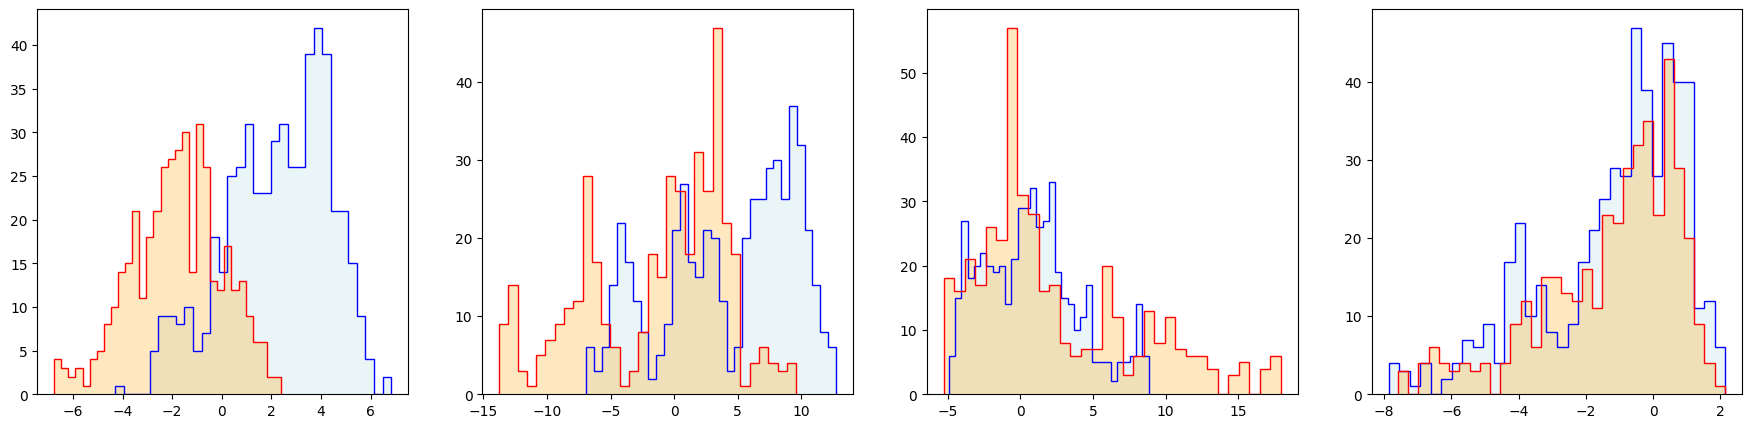

In [10]:
fig, ax = plt.subplots(1,4, figsize=(22,5))
for i in range(4):
    ax[i].hist(data_train[lbls_train==0].iloc[:,i], bins=32, histtype='step', color='blue')
    ax[i].hist(data_train[lbls_train==1].iloc[:,i], bins=32, histtype='step', color='red')
    ax[i].hist(data_train[lbls_train==0].iloc[:,i], bins=32, histtype='bar', color='lightblue', alpha=0.25)
    ax[i].hist(data_train[lbls_train==1].iloc[:,i], bins=32, histtype='bar', color='orange', alpha =0.25)

## Problem 1

Using  the [GaussianNB](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html) function construct the  Gaussian  Bayes classifier using only one feature. Which feature will you choose? Calculate the confusion matrix (normalized as to show rates), ROC AUC score and plot ROC curve. Do this both for training and validation set. Plot both curves on the same plot.  

In [11]:
# split features and data

features = ['a0', 'a1', 'a2', 'a3']
X = data[features]
y = data['counterfeit']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, shuffle=True, stratify=y, random_state=seed)

In [12]:
# find best feature

best_feature = None
best_val_auc = -1
feature_performance = {}

for col in features:
    # separate classes
    class_0 = X_train.loc[y_train == 0, col]
    class_1 = X_train.loc[y_train == 1, col]

    # normal distribution
    mu_0, std_0 = st.norm.fit(class_0)
    mu_1, std_1 = st.norm.fit(class_1)

    # GaussianNB eval
    clf = GaussianNB()
    clf.fit(X_train[[col]], y_train)

    # validation probabilities
    val_probs = clf.predict_proba(X_val[[col]])[:, 1]
    val_auc = roc_auc_score(y_val, val_probs)
    feature_performance[col] = val_auc

    print(f'feature {col}: ROC AUC = {val_auc:.4f}')
    print(f'  Class 0 (Authentic):  mean = {mu_0:.4f}, std = {std_0:.4f}')
    print(f'  Class 1 (Counterfeit): mean = {mu_1:.4f}, std = {std_1:.4f}')

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_feature = col

print(f'Chosen feature: {best_feature}')

feature a0: ROC AUC = 0.9443
  Class 0 (Authentic):  mean = 2.2528, std = 2.0779
  Class 1 (Counterfeit): mean = -1.8099, std = 1.8127
feature a1: ROC AUC = 0.7328
  Class 0 (Authentic):  mean = 4.3104, std = 5.1409
  Class 1 (Counterfeit): mean = -1.2679, std = 5.5346
feature a2: ROC AUC = 0.5443
  Class 0 (Authentic):  mean = 0.7670, std = 3.2610
  Class 1 (Counterfeit): mean = 2.3411, std = 5.5402
feature a3: ROC AUC = 0.5151
  Class 0 (Authentic):  mean = -1.1909, std = 2.1247
  Class 1 (Counterfeit): mean = -1.2583, std = 2.0217
Chosen feature: a0


In [13]:
# train model on chosen feature

clf_final = GaussianNB()
clf_final.fit(X_train[[best_feature]], y_train)

train_probs = clf_final.predict_proba(X_train[[best_feature]])[:, 1]
val_probs = clf_final.predict_proba(X_val[[best_feature]])[:, 1]

train_preds = clf_final.predict(X_train[[best_feature]])
val_preds = clf_final.predict(X_val[[best_feature]])

In [14]:
# confusion matrices (normalized)

cm_train = confusion_matrix(y_train, train_preds, normalize='true')
cm_validation = confusion_matrix(y_val, val_preds, normalize='true')

print("confusion matrix (train)")
print(pd.DataFrame(cm_train, columns=['Pred 0', 'Pred 1'], index=['Actual 0', 'Actual 1']))

print("confusion matrix (test)")
print(pd.DataFrame(cm_validation, columns=['Pred 0', 'Pred 1'], index=['Actual 0', 'Actual 1']))

confusion matrix (train)
            Pred 0    Pred 1
Actual 0  0.853282  0.146718
Actual 1  0.171498  0.828502
confusion matrix (test)
            Pred 0    Pred 1
Actual 0  0.876923  0.123077
Actual 1  0.182692  0.817308


In [15]:
# ROC AUC scores

auc_train = roc_auc_score(y_train, train_probs)
auc_validation = roc_auc_score(y_val, val_probs)

print(f"final ROC AUC (train): {auc_train:.4f}")
print(f"final ROC AUC (test): {auc_validation:.4f}")

final ROC AUC (train): 0.9217
final ROC AUC (test): 0.9443


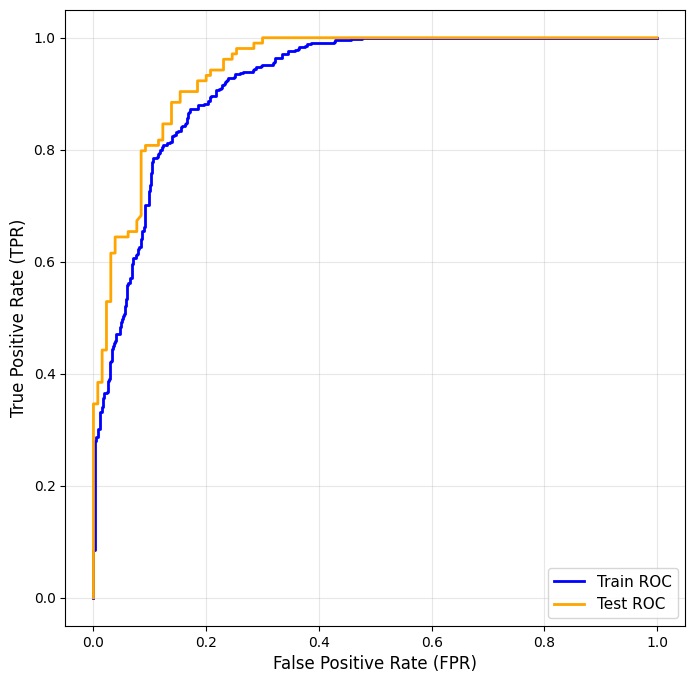

In [16]:
# plot both ROC curves

fpr_train, tpr_train, _ = roc_curve(y_train, train_probs)
fpr_val, tpr_val, _ = roc_curve(y_val, val_probs)

plt.figure(figsize=(8, 8))
plt.plot(fpr_train, tpr_train, label=f'Train ROC', color='blue', lw=2)
plt.plot(fpr_val, tpr_val, label=f'Test ROC', color='orange', lw=2)

plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()